In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd ..

/


In [4]:
%cd /content/drive/MyDrive/yolo
!ls

/content/drive/MyDrive/yolo
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [5]:
!pip install ultralytics==8.0.77 optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.4/513.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 8.6 MB/s eta 0:00:00


In [6]:
import optuna
from ultralytics import YOLO
import os

DATA_YAML = "/content/drive/MyDrive/yolo/data.yaml"  # Ajusta la ruta a tu data.yaml

def objective(trial):
    """
    Función objetivo de Optuna. Entrena YOLOv8 con distintos hiperparámetros
    y devuelve la métrica mAP para decidir cuál es mejor.
    """
    # 1. Escoger modelo base
    model_size = trial.suggest_categorical("model_size", ["yolov8n.pt", "yolov8s.pt"])

    # 2. Escoger lr0 (learning rate inicial)
    lr0 = trial.suggest_categorical("lr0", [1e-3, 1e-4])

    # 3. Definimos un nombre único para cada experimento
    exp_name = f"trial_{trial.number}_model_{model_size.split('.')[0]}_lr_{lr0}"

    # 4. Creamos el modelo
    model = YOLO(model_size)

    # 5. Entrenamos con los overrides de hiperparámetros
    #    - epochs=25
    #    - patience=5 => si 5 épocas seguidas sin mejora, se detiene antes
    #    - project => para que todos los runs se guarden en la misma carpeta (optuna_yolo)
    results = model.train(
        data=DATA_YAML,
        epochs=25,
        patience=5,
        imgsz=640,
        batch=16,
        lr0=lr0,  # Tasa de aprendizaje
        project="optuna_yolo",  # carpeta donde se guardan runs
        name=exp_name,
        verbose=False  # para no saturar la consola
    )

    # 6. Al terminar el entrenamiento, validamos para obtener métricas
    val_results = model.val()

    # 7. Recuperar mAP 0.5:0.95 (box.map)
    #    (También podrías usar val_results.box.map50 si te interesa mAP@0.5)
    map_5095 = val_results.box.map

    # 8. Devolvemos la métrica que queremos maximizar
    #    Optuna por defecto minimiza, así que podemos retornar -map_5095 para forzar maximización
    return -map_5095

# Creamos el estudio de Optuna
study = optuna.create_study(direction="minimize")  # Minimiza la métrica negativa => max mAP
study.optimize(objective, n_trials=2)  # con 2 pruebas basta de ejemplo, tú puedes poner 3, 4, etc.

print("===== Mejores resultados =====")
print("Best Trial:", study.best_trial)
print("Best Params:", study.best_params)
print("Best Value (neg. mAP):", study.best_value)


[I 2025-01-17 07:42:54,646] A new study created in memory with name: no-name-a0023758-a0b7-4fed-b076-995ee8036753
100%|██████████| 21.5M/21.5M [00:00<00:00, 141MB/s]
/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full contro

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...
100%|██████████| 6.23M/6.23M [00:00<00:00, 90.8MB/s]
/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on

===== Mejores resultados =====
Best Trial: FrozenTrial(number=0, state=1, values=[-0.8905734299206601], datetime_start=datetime.datetime(2025, 1, 17, 7, 42, 54, 648631), datetime_complete=datetime.datetime(2025, 1, 17, 8, 34, 37, 184747), params={'model_size': 'yolov8s.pt', 'lr0': 0.001}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model_size': CategoricalDistribution(choices=('yolov8n.pt', 'yolov8s.pt')), 'lr0': CategoricalDistribution(choices=(0.001, 0.0001))}, trial_id=0, value=None)
Best Params: {'model_size': 'yolov8s.pt', 'lr0': 0.001}
Best Value (neg. mAP): -0.8905734299206601


/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location='cpu'), file  # load


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
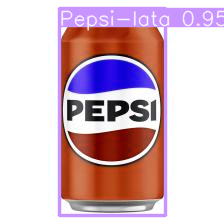

In [12]:
from ultralytics import YOLO

# 1. Carga tu modelo entrenado (el best.pt de tu trial ganador)
model = YOLO("optuna_yolo/trial_0_model_yolov8s_lr_0.001/weights/best.pt")  # Ajusta la ruta

# 2. Ejecuta inferencia sobre una imagen
results = model.predict(source="/content/drive/MyDrive/yolo/test/images/00750103131130L2_jpg.rf.1f8bda5d23038cfa6b8974ce30c4e496.jpg", conf=0.5, save=False)

# 3. Visualiza la imagen con bounding boxes
results[0].plot()   # Muestra en Colab una versión con las detecciones dibujadas
